# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [ ]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

# mlflow.set_tracking_uri("databricks")
# mlflow.set_registry_uri("databricks")

email = '202625679@alu.comillas.edu'

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # set_tracking_uri le dice a MLflow dónde guardar los runs
    # mlflow.set_tracking_uri("databricks")

    # set_experiment crea el experimento si no existe y hace que los siguientes runs se guarden en él
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)

    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

c:\Users\Byadr\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ MLflow configurado correctamente
📊 Experimento: /Users/202625679@alu.comillas.edu/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split separa los datos en entrenamiento y test
from sklearn.model_selection import train_test_split

# Un Pipeline encadena varios pasos (imputar, escalar, etc) para aplicarlos uno tras otro
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Modelos: SGDClassifier como modelo base y Random Forest como modelo más potente
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# cross_val_score hace validación cruzada: entrena y evalúa en k particiones distintas
from sklearn.model_selection import cross_val_score, cross_val_predict

# Métricas de clasificación, en medcina nos fijamos sobre todo en el recall
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [ ]:
# El csv tiene datos clínicos de pacientes, una fila por paciente
# La columna target indica si tiene enfermedad cardíaca (1) o no (0)
data = pd.read_csv('../data/raw/heart.csv')

print("Filas:", data.shape[0])
print("Columnas:", data.shape[1])
print("Variable objetivo: target")

Filas: 303
Columnas: 14
Variable objetivo: target


In [ ]:
# Sirve para ver cómo vienen los datos
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [ ]:
data.info()

'''
Numéricas: age, trestbps, chol, thalach, oldpeak, ca
Categóricas: sex, cp, fbs, restecg, exang, slope y thal
Hay nulos en trestbps y chol

'''

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    str    
 2   cp        303 non-null    str    
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    str    
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    str    
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    str    
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), str(5)
memory usage: 45.1 KB


In [ ]:
data.describe()

'''
- La edad va de 29 a 77 años, con media de 54
- chol tiene un máximo de 564, muy por encima del resto
- trestbps y chol tienen menos filas (258 y 273) porque tienen nulos
- ca llega a 4 y thal tiene algún 0
- Las escalas son muy disintas (oldpeak 0-6 y chol 130-560)

'''

,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

- La edad media es de 54 años, son pacientes bastante mayores, que es lo normal en un estudio de corazón.
- Los rangos cambian mucho de una variable a otra: chol va de 131 a 564 y oldpeak de 0 a 6.2. Hay algún valor raro como el colesterol de 564.
- Hay nulos en trestbps (45) y chol (30).
- Habría que normalizar las numéricas (age, trestbps, chol, thalach, oldpeak) para que estén en la misma escala.


In [ ]:
target_counts = data.target.value_counts()
print(target_counts)
print()
print(data.target.value_counts(normalize=True).round(3))

# Hay un 54.5% de enfermos y un 45.5% de no enfermos, está bastante balanceado.

target
1    165
0    138
Name: count, dtype: int64

target
1    0.545
0    0.455
Name: proportion, dtype: float64


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

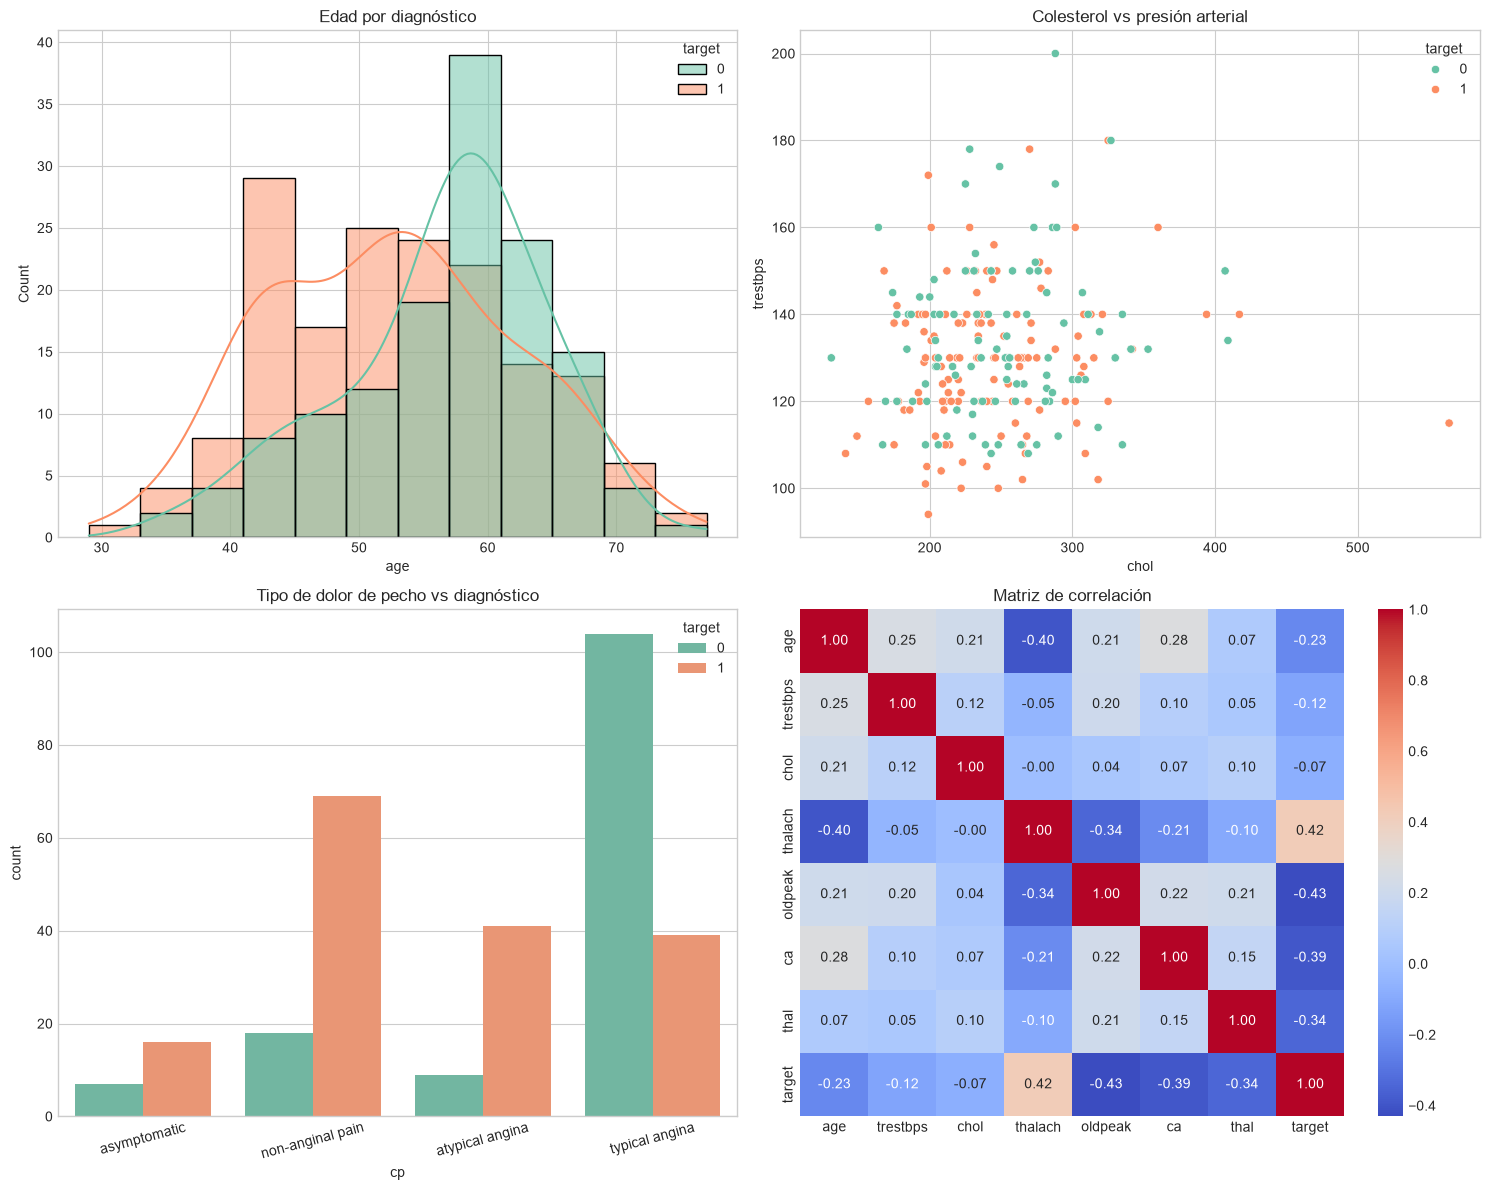

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(data=data, x='age', hue='target', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Edad por diagnóstico')

sns.scatterplot(data=data, x='chol', y='trestbps', hue='target', ax=axes[0, 1])
axes[0, 1].set_title('Colesterol vs presión arterial')

sns.countplot(data=data, x='cp', hue='target', ax=axes[1, 0])
axes[1, 0].set_title('Tipo de dolor de pecho vs diagnóstico')
axes[1, 0].tick_params(axis='x', rotation=15)

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal', 'target']
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de correlación')

plt.tight_layout()
plt.show()

'''
- Thalach (frecuencia máxima) es más alta en los enfermos y oldpeak y ca más bajos
- El colesterol y la presión no separan casi nada las dos clases, los puntos están mezclados
'''

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [9]:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

print("Train:", train_set.shape)
print("Test:", test_set.shape)

Train: (242, 14)
Test: (61, 14)


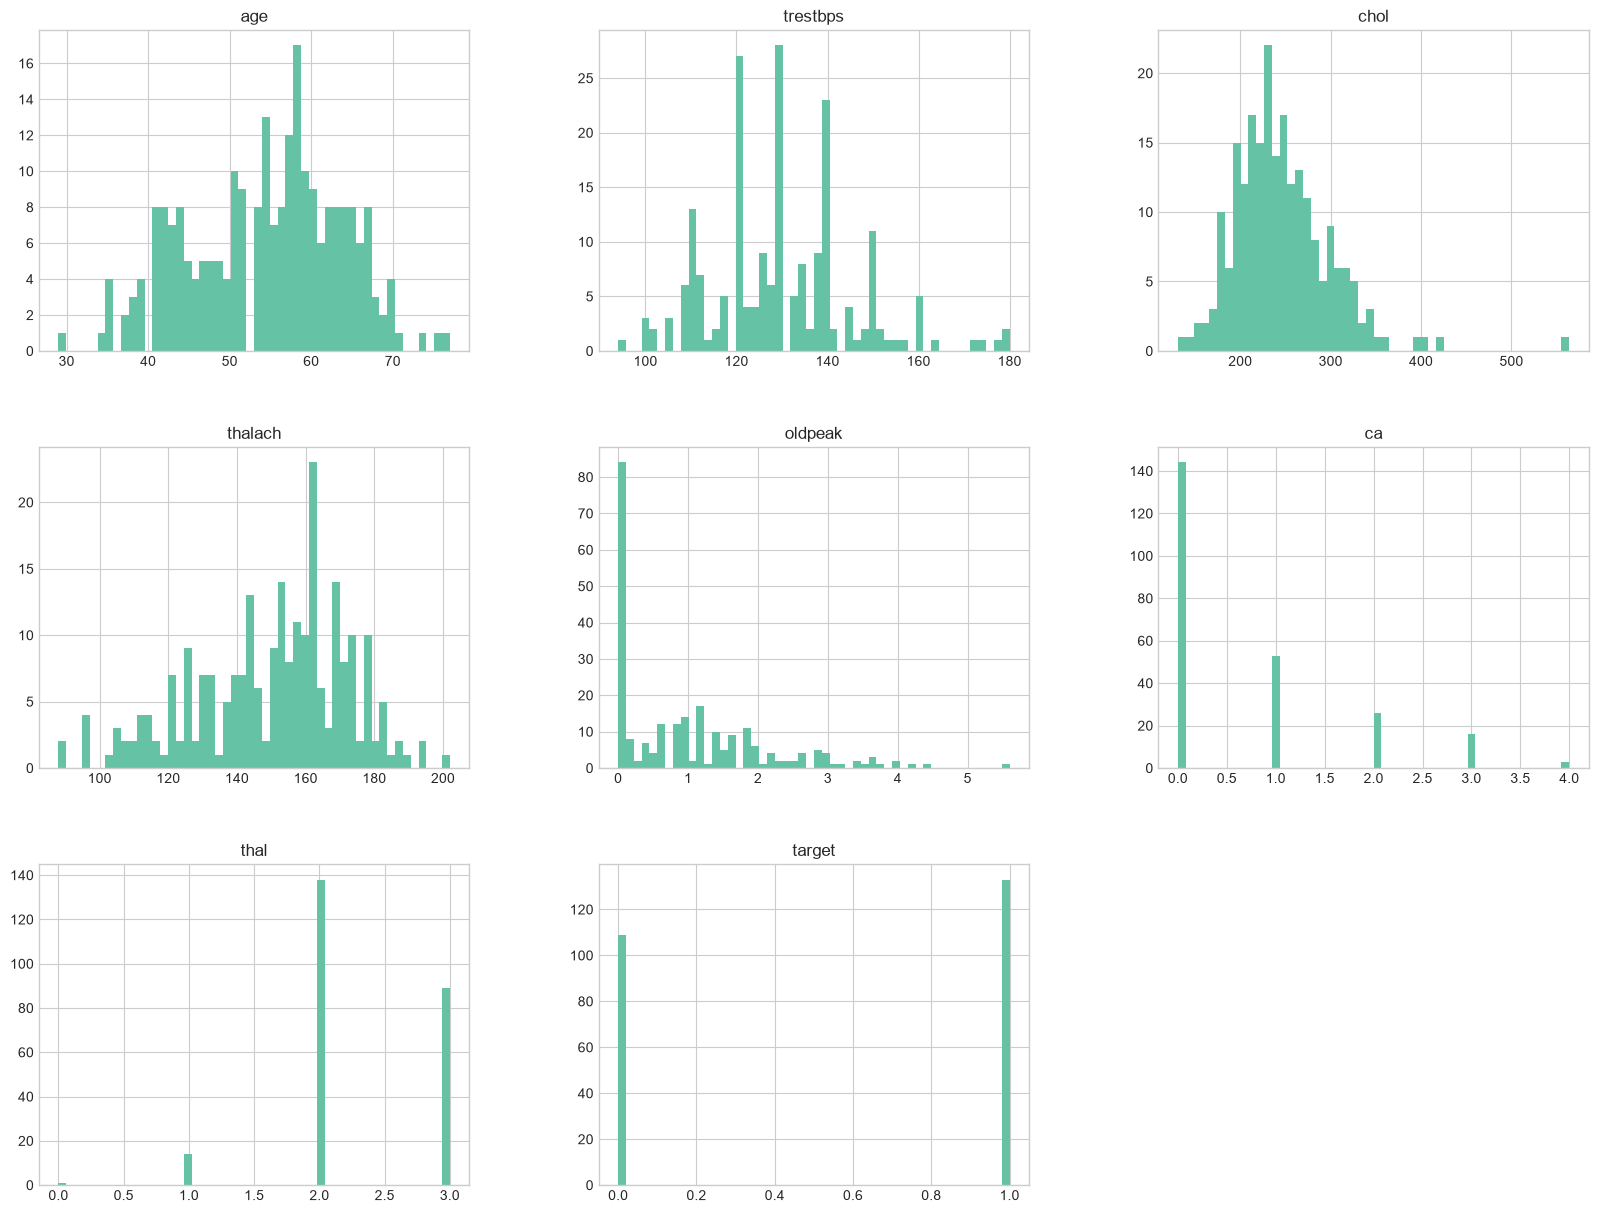

In [ ]:
train_set.hist(bins=50, figsize=(20, 15))
plt.show()

# age, trestbps, chol y thalach están en escalas de decenas o cientos y oldpeak o ca de 0 a 6.

### 📏 Observación Importante: Escalas Diferentes

**¿Por qué es un problema que las características tengan escalas diferentes?**

Porque las variables con valores grandes (como chol, que va hasta 564) ganana importancia sobre las pequeñas (como oldpeak) aunque no sean más importantes.

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

**¿Qué transformación aplicarías para que las variables numéricas sean comparables?**

Un StandardScaler, que deja cada variable con media 0 y desviación 1.

**¿Por qué esto ayuda a algunos modelos de Machine Learning?**

Algunos modelos funcionan mejor con los datos escalados. A los árboles como Random Forest les da igual.


## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [ ]:
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

# Para las numéricas, relleno los nulos con la mediana y luego estandarizo
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])

# El ColumnTransformer aplica cada transformación a sus columnas y junta el resultado
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attr),
])


# Uso One-Hot Encoding porque las categóricas no tienen orden. Si pongo cp como 0,1,2,3
# el modelo pensaría que 3 es mas importanteque 1. Con one-hot cada valor es una columna 0/1

## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [12]:
x_train = train_set.drop("target", axis=1)
y_train = train_set.target

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

x_train: (242, 13)
y_train: (242,)


In [ ]:
x_train_pr = full_pipeline.fit_transform(x_train)

# fit_transform aprende los parámetros (medianas, medias etc) con train y los aplica.
# transform solo aplica lo que ya el modelo aprendió, por eso en test se usa solo transform
print("Columnas antes:", x_train.shape[1])
print("Columnas después:", x_train_pr.shape[1])

Columnas antes: 13
Columnas después: 26


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?** Es un clasificador lineal  que se entrena con descenso de gradiente, es decir, en vez de usar todos los datos a la vez, va actualizando los pesos muestra a muestra para ir reduciendo el error. Es rápido y simple, por eso sirve como baseline.

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [ ]:
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
    sgd_clf = SGDClassifier(random_state=42)

    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=5, scoring="accuracy")

    mlflow.log_metric("cv_accuracy_media", scores.mean())
    mlflow.log_metric("cv_accuracy_std", scores.std())

    # guardo el id del run para luego añadirle las demás métricas
    sgd_run_id = run.info.run_id

print("Accuracy en cada fold:", scores.round(3))
print("Media:", round(scores.mean(), 3))

# Sale una accuracy media de 0.78, aunque varía bastante entre folds (de 0.69 a 0.86).
# No está mal para un modelo simple

2026/10/02 12:37:35 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:37:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:37:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:37:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe

Accuracy en cada fold: [0.694 0.857 0.792 0.729 0.833]
Media: 0.781


### 📊 Evaluación del Modelo SGD

In [ ]:
# Lo hago dentro del mismo run porque si no el autolog crea un run nuevo por cada fold
with mlflow.start_run(run_id=sgd_run_id):
    preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=5)
    sgd_scores = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=5, method="decision_function")

# cross_val_predict devuelve la predicción de cada fila hecha por un modelo que no la vio al entrenar.
# Así puedo sacar la matriz de cofusión y las métricas sin usar el test

2026/10/02 12:38:07 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:38:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:38:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:38:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe

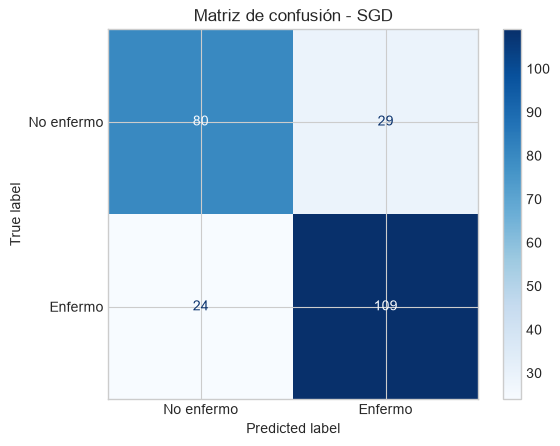

In [ ]:
cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No enfermo", "Enfermo"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - SGD")
plt.show()

'''
TN = 80 sanos bien clasificados, FP = 29 sanos que predice como enfermos,
FN = 24 enfermos que el modelo no detecta, TP = 109 enfermos bien detectados.
En medicina lo más grave son los FN: a un enfermo se le diría que está sano y no se le trataría.

'''

In [ ]:
precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, sgd_scores)

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1:", round(f1, 3))
print("ROC AUC:", round(roc_auc, 3))

with mlflow.start_run(run_id=sgd_run_id):
    mlflow.log_metric("cv_precision", precision)
    mlflow.log_metric("cv_recall", recall)
    mlflow.log_metric("cv_f1", f1)
    mlflow.log_metric("cv_roc_auc", roc_auc)

'''
Precision 0.79, recall 0.82, F1 0.80 y AUC 0.85.
La más importante en medicina es el recall, porque mide cuántos enfermos detectamos.
Con 0.82 se escapa casi el 20% de enfermos


'''

Precision: 0.79
Recall: 0.82
F1: 0.804
ROC AUC: 0.845


### 🌲 Modelo 2: Random Forest Classifier

**¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?** Es un conjunto de muchos árboles de decisión, cada uno entrenado con una muestra aleatoria de los datos y de las variables. La predicción final es la aportacion de todos. Suele funcionar mejor que un modelo lineal porque capta relaciones no lineales.

Ahora probemos un modelo más potente y comparemos resultados.

In [ ]:
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=5, scoring="accuracy")
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=5)
    rf_proba = cross_val_predict(rf_clf, x_train_pr, y_train, cv=5, method="predict_proba")[:, 1]

    mlflow.log_metric("cv_accuracy_media", rf_scores.mean())
    mlflow.log_metric("cv_accuracy_std", rf_scores.std())
    rf_run_id = run.info.run_id

print("Accuracy en cada fold:", rf_scores.round(3))
print("Media:", round(rf_scores.mean(), 3))

# Se podrían ajustar n_estimators (número de árboles), max_depth o min_samples_leaf para controlar el overfitting.
# Lo comparo con el SGD porque es la línea base. Si un modelo más complejo no mejora al simple, no merece la pena

2026/10/02 12:39:06 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:39:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:39:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:39:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe

Accuracy en cada fold: [0.837 0.837 0.812 0.854 0.792]
Media: 0.826


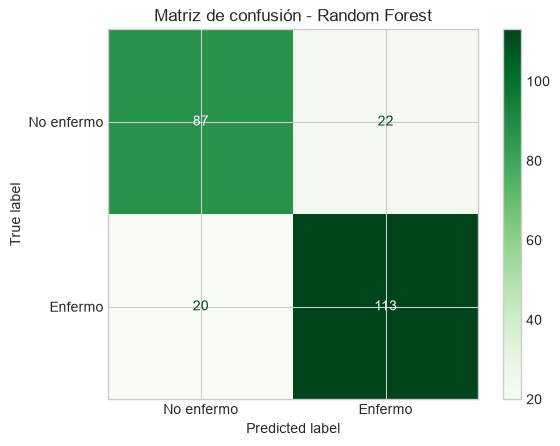

In [19]:
cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No enfermo", "Enfermo"])
disp_rf.plot(cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.show()

# Random Forest: TN = 87, FP = 22, FN = 20, TP = 113.
# Comete menos errores de los dos tipos que el SGD: 4 falsos negativos menos (20 vs 24) y 7 falsos positivos menos

In [20]:
rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_proba)

with mlflow.start_run(run_id=rf_run_id):
    mlflow.log_metric("cv_precision", rf_precision)
    mlflow.log_metric("cv_recall", rf_recall)
    mlflow.log_metric("cv_f1", rf_f1)
    mlflow.log_metric("cv_roc_auc", rf_roc_auc)

comparacion = pd.DataFrame({
    "SGD": [scores.mean(), precision, recall, f1, roc_auc],
    "Random Forest": [rf_scores.mean(), rf_precision, rf_recall, rf_f1, rf_roc_auc],
}, index=["accuracy", "precision", "recall", "f1", "roc_auc"])
print(comparacion.round(3))

# Random Forest es mejor en todas las métricas, sobre todo en AUC (0.89 vs 0.85) y en recall (0.85 vs 0.82).
# Me quedo con Random Forest como modelo final

             SGD  Random Forest
accuracy   0.781          0.826
precision  0.790          0.837
recall     0.820          0.850
f1         0.804          0.843
roc_auc    0.845          0.894


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [21]:
with mlflow.start_run(run_name="Random Forest - Final") as run:
    forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
    forest_clf.fit(x_train_pr, y_train)
    final_run_id = run.info.run_id

# Ahora entreno con todo el train porque la validación cruzada era solo para elegir modelo.
# Con más datos el modelo final aprende mejor

2026/10/02 12:40:35 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:40:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [22]:
x_test = test_set.drop("target", axis=1)
y_test = test_set.target

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_test: (61, 13)
y_test: (61,)


In [ ]:
x_test_pr = full_pipeline.transform(x_test)
final_preds = forest_clf.predict(x_test_pr)
final_proba = forest_clf.predict_proba(x_test_pr)[:, 1]

# En test solo uso transform() para aplicar las medias, medianas y categorías aprendidas en train.
# Si hiciera fit_transform estaría usando información del test y la evaluación no valdría

Accuracy: 0.869
Precision: 0.875
Recall: 0.875
F1: 0.875
ROC AUC: 0.936


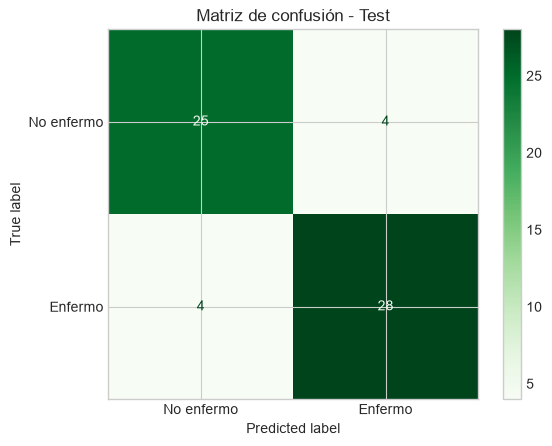

              precision    recall  f1-score   support

  No enfermo       0.86      0.86      0.86        29
     Enfermo       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_proba)
final_accuracy = accuracy_score(y_test, final_preds)

print("Accuracy:", round(final_accuracy, 3))
print("Precision:", round(final_precision, 3))
print("Recall:", round(final_recall, 3))
print("F1:", round(final_f1, 3))
print("ROC AUC:", round(final_roc_auc, 3))

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_metric("test_accuracy", final_accuracy)
    mlflow.log_metric("test_precision", final_precision)
    mlflow.log_metric("test_recall", final_recall)
    mlflow.log_metric("test_f1", final_f1)
    mlflow.log_metric("test_roc_auc", final_roc_auc)

cm_final = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["No enfermo", "Enfermo"]).plot(cmap="Greens")
plt.title("Matriz de confusión - Test")
plt.show()

print(classification_report(y_test, final_preds, target_names=["No enfermo", "Enfermo"]))

'''
En test sale accuracy 0.87, recall 0.875 y AUC 0.94, incluso algo mejor que en la validación cruzada.
Falla 4 enfermos y 4 sanos de 61 pacientes. Generaliza bien, no parece que haya overfitting,

'''


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [x] Exploración de datos médicos reales
2. [x] Pipeline de preprocesamiento
3. [x] Entrenamiento y comparación de modelos
4. [x] Evaluación con métricas de clasificación
5. [x] Validación cruzada
6. [x] Registro de experimentos en MLflow
7. [x] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave



1. **¿Qué modelo funcionó mejor?**
   - Random Forest. En validación cruzada fue mejor que el SGD en todo (recall 0.85 vs 0.82, AUC 0.89 vs 0.85) y en test sacó 0.87 de accuracy y 0.94 de AUC.

2. **¿Por qué crees que funcionó mejor?**
   - Porque combina muchos árboles y puede captar relaciones no lineales entre variables.

3. **¿El modelo es suficientemente bueno para uso médico?**
   - No. Se le escapan 4 de los 32 enfermos del test y además el dataset es muy pequeño (303 pacientes) y no está validado clínicamente.

4. **¿Qué métrica es más importante en este caso?**
   - El recall, porque lo peor es no detectar a un enfermo. 

5. **¿Qué mejorarías del modelo?**
   - Ajustaría hiperparámetros pensando en el recall (con GridSearch subió a 0.91 en test) e intentaía tener más datos.

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA



1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - Los falsos negativos. Un falso positivo implica hacer más pruebas, pero un falso negativo es un enfermo sin tratamiento.

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - No. Debe ser una herramienta de apoyo y la decisión final la tiene que tomar el médico, que además es quien responde de ella.

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - Porque si el médico no entiende por qué el modelo dice algo no puede saber si fiarse o no. Además así puede detectar errores, por ejemplo si el modelo se basa en una variable que no tiene sentido clínico.

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


2026/10/02 12:40:41 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:41:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:41:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:41:12 INFO mlflow.sklearn.

Mejores parámetros: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
Mejor recall en CV: 0.879
Test -> recall: 0.906  precision: 0.879  accuracy: 0.885


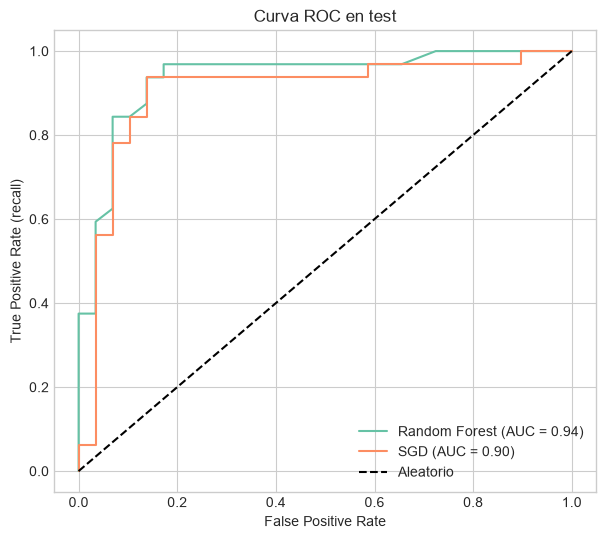

Umbral 0.5: recall = 0.875, precision = 0.875
Umbral 0.4: recall = 0.938, precision = 0.857
Umbral 0.3: recall = 0.969, precision = 0.838
num__ca                   0.117
num__oldpeak              0.107
num__thalach              0.086
num__age                  0.074
cat__cp_typical angina    0.073
num__chol                 0.062
cat__thal_2               0.061
num__trestbps             0.061
cat__thal_3               0.058
cat__exang_No             0.053
dtype: float64


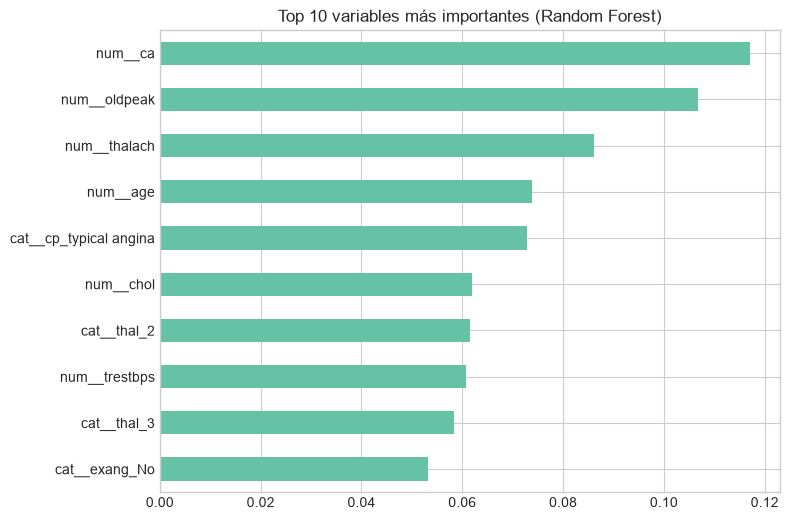

2026/10/02 12:41:18 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:41:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:41:24 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:41:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe

                modelo  accuracy  recall  precision     f1
2        Random Forest     0.826   0.850      0.837  0.843
1  Logistic Regression     0.802   0.842      0.806  0.824
3    Gradient Boosting     0.793   0.827      0.803  0.815
0                  SGD     0.781   0.820      0.790  0.804
4                  SVM     0.802   0.820      0.820  0.820


In [ ]:
# 🎨 DESAFÍOS OPCIONALES

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# ========================================
# DESAFÍO 1 - Grid Search
# ========================================
# Uso recall como métrica porque es la que más importa aquí
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 3, 5],
}

with mlflow.start_run(run_name="Random Forest - GridSearch"):
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall')
    grid_search.fit(x_train_pr, y_train)

    grid_preds = grid_search.predict(x_test_pr)
    mlflow.log_metric("test_recall", recall_score(y_test, grid_preds))
    mlflow.log_metric("test_precision", precision_score(y_test, grid_preds))
    mlflow.log_metric("test_accuracy", accuracy_score(y_test, grid_preds))

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor recall en CV:", round(grid_search.best_score_, 3))
print("Test -> recall:", round(recall_score(y_test, grid_preds), 3),
      " precision:", round(precision_score(y_test, grid_preds), 3),
      " accuracy:", round(accuracy_score(y_test, grid_preds), 3))

# ========================================
# DESAFÍO 2 - Curva ROC
# ========================================
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, final_proba)
sgd_final = SGDClassifier(random_state=42).fit(x_train_pr, y_train)
fpr_sgd, tpr_sgd, _ = roc_curve(y_test, sgd_final.decision_function(x_test_pr))

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {final_roc_auc:.2f})")
plt.plot(fpr_sgd, tpr_sgd, label=f"SGD (AUC = {roc_auc_score(y_test, sgd_final.decision_function(x_test_pr)):.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (recall)")
plt.title("Curva ROC en test")
plt.legend()
plt.show()

# Pruebo a bajar el umbral para detectar más enfermos
for umbral in [0.5, 0.4, 0.3]:
    pred_umbral = (final_proba >= umbral).astype(int)
    print(f"Umbral {umbral}: recall = {recall_score(y_test, pred_umbral):.3f}, precision = {precision_score(y_test, pred_umbral):.3f}")

# ========================================
# DESAFÍO 3 - Importancia de características
# ========================================
feature_names = full_pipeline.get_feature_names_out()
feature_importance = pd.Series(forest_clf.feature_importances_, index=feature_names).sort_values(ascending=False)
print(feature_importance.head(10).round(3))

feature_importance.head(10).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Top 10 variables más importantes (Random Forest)")
plt.show()

# ========================================
# DESAFÍO 4 - Comparar más modelos
# ========================================
modelos = {
    'SGD': SGDClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
}

resultados = []
for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=f"Comparacion - {nombre}"):
        pred_cv = cross_val_predict(modelo, x_train_pr, y_train, cv=5)
        acc = accuracy_score(y_train, pred_cv)
        rec = recall_score(y_train, pred_cv)
        prec = precision_score(y_train, pred_cv)
        f1_m = f1_score(y_train, pred_cv)
        mlflow.log_metric("cv_accuracy", acc)
        mlflow.log_metric("cv_recall", rec)
        mlflow.log_metric("cv_precision", prec)
        mlflow.log_metric("cv_f1", f1_m)
        resultados.append({'modelo': nombre, 'accuracy': acc, 'recall': rec, 'precision': prec, 'f1': f1_m})

print(pd.DataFrame(resultados).sort_values('recall', ascending=False).round(3))

'''
Conclusiones de los desafíos:
- El GridSearch elige árboles poco profundos (max_depth=3) y mejora el recall en test a 0.91
- Bajando el umbral a 0.4 el recall sube a 0.94 perdiendo poca precision
- Las variables más importantes son ca, oldpeak, thalach y age, que coinciden con las más del EDA
- Random Forest sigue siendo el mejor de los modelos probados
'''